In [33]:
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
 df_players = pd.read_csv('players.csv')
df_players.drop(columns=['first_name','last_name','name','country_of_birth','city_of_birth','agent_name','url'],inplace=True,errors='ignore')
inactive_players_index=df_players[df_players['last_season']<2025].index
df_players.drop(index=inactive_players_index,inplace=True)
df_players.dropna(subset=['current_club_name'],inplace=True)
df_players['international_goals'].fillna(0,inplace=True)
df_players['current_national_team_id'].fillna('non_international',inplace=True)
df_players['international_caps'].fillna(0,inplace=True)
df_players['date_of_birth'] = pd.to_datetime(df_players['date_of_birth'])
df_players['annee']=df_players['date_of_birth'].dt.year
df_players['age']=2026-df_players['annee']

display(df_players.head())

/tmp/ipykernel_10138/1994731151.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_players['international_goals'].fillna(0,inplace=True)
/tmp/ipykernel_10138/1994731151.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

,player_id,last_season,current_club_id,player_code,country_of_citizenship,date_of_birth,sub_position,position,foot,height_in_cm,...,image_url,international_caps,international_goals,current_national_team_id,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur,annee,age
189,3333,2025,1237,james-milner,England,1986-01-04,Central Midfield,Midfield,right,175.0,...,https://img.a.transfermarkt.technology/portrai...,61.0,1.0,non_international,GB1,Brighton and Hove Albion Football Club,750000.0,21000000.0,1986,40
418,5336,2025,60949,anastasios-tsokanis,Greece,1991-05-02,Defensive Midfield,Midfield,left,176.0,...,https://img.a.transfermarkt.technology/portrai...,0.0,0.0,non_international,GR1,Volou Neos Podosferikos Syllogos,200000.0,450000.0,1991,35
645,7161,2025,15,jonas-hofmann,Germany,1992-07-14,Attacking Midfield,Midfield,right,176.0,...,https://img.a.transfermarkt.technology/portrai...,23.0,4.0,non_international,L1,Bayer 04 Leverkusen Fußball,2000000.0,16000000.0,1992,34
742,7966,2025,189,javier-garcia,Argentina,1987-01-29,Goalkeeper,Goalkeeper,right,180.0,...,https://img.a.transfermarkt.technology/portrai...,1.0,0.0,non_international,ARG1,Club Atlético Boca Juniors,25000.0,900000.0,1987,39
760,8198,2025,18544,cristiano-ronaldo,Portugal,1985-02-05,Centre-Forward,Attack,right,188.0,...,https://img.a.transfermarkt.technology/portrai...,226.0,143.0,non_international,SA1,Al-Nassr Football Club,12000000.0,120000000.0,1985,41


In [35]:
df_clubs = pd.read_csv('clubs.csv')
df_clubs.drop(columns=['total_market_value',	'squad_size',	'average_age',	'foreigners_number',	'foreigners_percentage',	'national_team_players',	'stadium_name',	'stadium_seats',	'net_transfer_record',	'coach_name','total_players','filename',	'url'],inplace=True,errors='ignore')
inactive_clubs_index=df_clubs[df_clubs['last_season']<2025].index
df_clubs.drop(index=inactive_clubs_index,inplace=True)
display(df_clubs.head())

,club_id,club_code,name,domestic_competition_id,last_season
1,10004,paris-fc,Paris Football Club,FR1,2025
2,10010,esporte-clube-bahia,Esporte Clube Bahia,BRA1,2025
4,1005,us-lecce,Unione Sportiva Lecce,IT1,2025
5,10090,deportivo-pasto,Asociación Deportivo Pasto,COL1,2025
6,10093,independiente-medellin,Independiente Medellín,COL1,2025


In [36]:
df_competition=pd.read_csv('competitions.csv')
national_team_competition_index=df_competition[df_competition['type']!='domestic_league'].index
df_competition.drop(index=national_team_competition_index,inplace=True)
df_competition.drop(columns=['sub_type',	'type',	'total_clubs',	'url'],inplace=True,errors='ignore')

display(df_competition.head())

,competition_id,competition_code,name,country_id,country_name,domestic_league_code,confederation
0,A1,bundesliga,bundesliga,127,Austria,A1,europa
3,ARG1,torneo-apertura,torneo-apertura,9,Argentina,ARG1,amerika
4,AUS1,a-league-men,a-league-men,12,Australia,AUS1,asien
5,BE1,jupiler-pro-league,jupiler-pro-league,19,Belgium,BE1,europa
7,BRA1,campeonato-brasileiro-serie-a,campeonato-brasileiro-serie-a,26,Brazil,BRA1,amerika


In [37]:
df_appearances = pd.read_csv('appearances.csv')
df_appearances.drop(
    columns=['game_id', 'player_club_id', 'player_current_club_id',
             'player_name', 'competition_id', 'date'],
    inplace=True,
    errors='ignore'
)

df_total_performance = df_appearances.groupby('player_id').agg(
    total_goals= ('goals','sum'),
    total_assists= ('assists','sum'),
    total_minutes= ('minutes_played','sum'),
    total_yellow_card = ('yellow_cards','sum'),
    total_red_cards= ('red_cards','sum'),
    total_appearances= ('appearance_id','count')
).reset_index()

display(df_total_performance.head())

df_palyers_pef=pd.merge(df_players,df_total_performance, on='player_id',how='inner')
display(df_palyers_pef.head())
df_palyers_pef_club=pd.merge(df_palyers_pef,df_clubs,left_on='current_club_id',right_on='club_id',how='inner')
display(df_palyers_pef_club.head())
df_scout=pd.merge(df_palyers_pef_club,df_competition,left_on='domestic_competition_id',right_on='competition_id',how='inner')
display(df_scout.head())

,player_id,total_goals,total_assists,total_minutes,total_yellow_card,total_red_cards,total_appearances
0,10,18.0,5.0,3340.0,9.0,0.0,46
1,26,0.0,0.0,5976.0,3.0,2.0,67
2,65,16.0,5.0,3975.0,3.0,0.0,46
3,77,0.0,0.0,307.0,0.0,0.0,4
4,80,0.0,0.0,450.0,0.0,0.0,5


,player_id,last_season,current_club_id,player_code,country_of_citizenship,date_of_birth,sub_position,position,foot,height_in_cm,...,market_value_in_eur,highest_market_value_in_eur,annee,age,total_goals,total_assists,total_minutes,total_yellow_card,total_red_cards,total_appearances
0,3333,2025,1237,james-milner,England,1986-01-04,Central Midfield,Midfield,right,175.0,...,750000.0,21000000.0,1986,40,4.0,10.0,2960.0,5.0,1.0,50
1,5336,2025,60949,anastasios-tsokanis,Greece,1991-05-02,Defensive Midfield,Midfield,left,176.0,...,200000.0,450000.0,1991,35,0.0,0.0,1591.0,3.0,0.0,31
2,7161,2025,15,jonas-hofmann,Germany,1992-07-14,Attacking Midfield,Midfield,right,176.0,...,2000000.0,16000000.0,1992,34,1.0,7.0,479.0,0.0,0.0,20
3,8198,2025,18544,cristiano-ronaldo,Portugal,1985-02-05,Centre-Forward,Attack,right,188.0,...,12000000.0,120000000.0,1985,41,80.0,20.0,6216.0,16.0,1.0,73
4,10471,2025,679,luiz-gustavo,Brazil,1987-07-23,Defensive Midfield,Midfield,left,187.0,...,200000.0,22000000.0,1987,39,5.0,1.0,3075.0,15.0,0.0,48


,player_id,last_season_x,current_club_id,player_code,country_of_citizenship,date_of_birth,sub_position,position,foot,height_in_cm,...,total_assists,total_minutes,total_yellow_card,total_red_cards,total_appearances,club_id,club_code,name,domestic_competition_id,last_season_y
0,3333,2025,1237,james-milner,England,1986-01-04,Central Midfield,Midfield,right,175.0,...,10.0,2960.0,5.0,1.0,50,1237,brighton-amp-hove-albion,Brighton and Hove Albion Football Club,GB1,2025
1,5336,2025,60949,anastasios-tsokanis,Greece,1991-05-02,Defensive Midfield,Midfield,left,176.0,...,0.0,1591.0,3.0,0.0,31,60949,volos-nps,Volou Neos Podosferikos Syllogos,GR1,2025
2,7161,2025,15,jonas-hofmann,Germany,1992-07-14,Attacking Midfield,Midfield,right,176.0,...,7.0,479.0,0.0,0.0,20,15,bayer-04-leverkusen,Bayer 04 Leverkusen Fußball,L1,2025
3,8198,2025,18544,cristiano-ronaldo,Portugal,1985-02-05,Centre-Forward,Attack,right,188.0,...,20.0,6216.0,16.0,1.0,73,18544,al-nasr-riad,Al-Nassr Football Club,SA1,2025
4,10471,2025,679,luiz-gustavo,Brazil,1987-07-23,Defensive Midfield,Midfield,left,187.0,...,1.0,3075.0,15.0,0.0,48,679,club-athletico-paranaense,Clube Atlético Paranaense,BRA1,2025


,player_id,last_season_x,current_club_id,player_code,country_of_citizenship,date_of_birth,sub_position,position,foot,height_in_cm,...,name_x,domestic_competition_id,last_season_y,competition_id,competition_code,name_y,country_id,country_name,domestic_league_code,confederation
0,3333,2025,1237,james-milner,England,1986-01-04,Central Midfield,Midfield,right,175.0,...,Brighton and Hove Albion Football Club,GB1,2025,GB1,premier-league,premier-league,189,England,GB1,europa
1,5336,2025,60949,anastasios-tsokanis,Greece,1991-05-02,Defensive Midfield,Midfield,left,176.0,...,Volou Neos Podosferikos Syllogos,GR1,2025,GR1,super-league-1,super-league-1,56,Greece,GR1,europa
2,7161,2025,15,jonas-hofmann,Germany,1992-07-14,Attacking Midfield,Midfield,right,176.0,...,Bayer 04 Leverkusen Fußball,L1,2025,L1,bundesliga,bundesliga,40,Germany,L1,europa
3,8198,2025,18544,cristiano-ronaldo,Portugal,1985-02-05,Centre-Forward,Attack,right,188.0,...,Al-Nassr Football Club,SA1,2025,SA1,saudi-pro-league,saudi-pro-league,146,Saudi Arabia,SA1,asien
4,10471,2025,679,luiz-gustavo,Brazil,1987-07-23,Defensive Midfield,Midfield,left,187.0,...,Clube Atlético Paranaense,BRA1,2025,BRA1,campeonato-brasileiro-serie-a,campeonato-brasileiro-serie-a,26,Brazil,BRA1,amerika


In [38]:
col_to_drop=['date_of_birth','last_season_x','domestic_competition_id','last_season_y','competition_id','name_y','country_id','domestic_league_code','last_season_y','competition_id','club_id','current_club_id']
df_scout.drop(columns=col_to_drop,inplace=True,errors='ignore')
unnecessary_cols=['contract_expiration_date','current_national_team_id','current_club_domestic_competition_id','annee','highest_market_value_in_eur','club_id','club_code']
df_scout.drop(columns=unnecessary_cols, inplace=True, errors='ignore')
display(df_scout.head(2))
df_scout.info()
df_scout.duplicated()
df_scout.duplicated().sum()
df_scout.isnull().sum()
df_scout['foot'].fillna('undefined', inplace=True)
df_scout['height_in_cm'].fillna('undefined', inplace=True)
df_scout['market_value_in_eur'].fillna('undefined', inplace=True)

,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_goals,total_assists,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation
0,3333,james-milner,England,Central Midfield,Midfield,right,175.0,https://img.a.transfermarkt.technology/portrai...,61.0,1.0,...,4.0,10.0,2960.0,5.0,1.0,50,Brighton and Hove Albion Football Club,premier-league,England,europa
1,5336,anastasios-tsokanis,Greece,Defensive Midfield,Midfield,left,176.0,https://img.a.transfermarkt.technology/portrai...,0.0,0.0,...,0.0,0.0,1591.0,3.0,0.0,31,Volou Neos Podosferikos Syllogos,super-league-1,Greece,europa


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 726 entries, 0 to 725
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_id               726 non-null    int64  
 1   player_code             726 non-null    object 
 2   country_of_citizenship  726 non-null    object 
 3   sub_position            726 non-null    object 
 4   position                726 non-null    object 
 5   foot                    725 non-null    object 
 6   height_in_cm            725 non-null    float64
 7   image_url               726 non-null    object 
 8   international_caps      726 non-null    float64
 9   international_goals     726 non-null    float64
 10  current_club_name       726 non-null    object 
 11  market_value_in_eur     726 non-null    float64
 12  age                     726 non-null    int32  
 13  total_goals             726 non-null    float64
 14  total_assists           726 non-null    fl

/tmp/ipykernel_10138/791584685.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_scout['foot'].fillna('undefined', inplace=True)
/tmp/ipykernel_10138/791584685.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [39]:
df_Goalkeeper= df_scout[df_scout['sub_position'] == 'Goalkeeper']
df_Goalkeeper['GK_rating']=df_Goalkeeper['total_appearances']/df_Goalkeeper['age']
df_Goalkeeper['market_value_in_eur'] = pd.to_numeric(df_Goalkeeper['market_value_in_eur'], errors='coerce')
df_Goalkeeper['deal_score'] = df_Goalkeeper['GK_rating'] / (df_Goalkeeper['market_value_in_eur'] * df_Goalkeeper['age'])
df_young_stars_index=df_Goalkeeper[df_Goalkeeper['age']>22].index
df_Goalkeeper.drop(index=df_young_stars_index, inplace=True)
display(df_Goalkeeper.head(10))
df_Goalkeeper.info()

/tmp/ipykernel_10138/3425321878.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Goalkeeper['GK_rating']=df_Goalkeeper['total_appearances']/df_Goalkeeper['age']
/tmp/ipykernel_10138/3425321878.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Goalkeeper['market_value_in_eur'] = pd.to_numeric(df_Goalkeeper['market_value_in_eur'], errors='coerce')
/tmp/ipykernel_10138/3425321878.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,GK_rating,deal_score


<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_id               0 non-null      int64  
 1   player_code             0 non-null      object 
 2   country_of_citizenship  0 non-null      object 
 3   sub_position            0 non-null      object 
 4   position                0 non-null      object 
 5   foot                    0 non-null      object 
 6   height_in_cm            0 non-null      object 
 7   image_url               0 non-null      object 
 8   international_caps      0 non-null      float64
 9   international_goals     0 non-null      float64
 10  current_club_name       0 non-null      object 
 11  market_value_in_eur     0 non-null      float64
 12  age                     0 non-null      int32  
 13  total_goals             0 non-null      float64
 14  total_assists           0 non-null      float64
 15  total_

In [40]:
df_Central_Midfield = df_scout[df_scout['sub_position'] == 'Central Midfield']
df_Central_Midfield['CM_rating']=df_Central_Midfield['total_appearances']/df_Central_Midfield['age']
df_Central_Midfield['market_value_in_eur'] = pd.to_numeric(df_Central_Midfield['market_value_in_eur'], errors='coerce')
df_Central_Midfield['deal_score'] = df_Central_Midfield['CM_rating'] / (df_Central_Midfield['market_value_in_eur'] * df_Central_Midfield['age'])
df_young_CM = df_Central_Midfield[df_Central_Midfield['age'] >22].index
df_Central_Midfield.drop(index=df_young_CM, inplace=True)
display(df_Central_Midfield.head())

/tmp/ipykernel_10138/4114639976.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Central_Midfield['CM_rating']=df_Central_Midfield['total_appearances']/df_Central_Midfield['age']
/tmp/ipykernel_10138/4114639976.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Central_Midfield['market_value_in_eur'] = pd.to_numeric(df_Central_Midfield['market_value_in_eur'], errors='coerce')
/tmp/ipykernel_10138/4114639976.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,CM_rating,deal_score


In [41]:
df_Defensive_Midfield = df_scout[df_scout['sub_position'] == 'Defensive Midfield']
df_Defensive_Midfield['DMF_rating']=df_Defensive_Midfield['total_minutes']/df_Defensive_Midfield['total_appearances']
df_Defensive_Midfield['market_value_in_eur'] = pd.to_numeric(df_Defensive_Midfield['market_value_in_eur'], errors='coerce')
df_Defensive_Midfield['deal_score'] = df_Defensive_Midfield['DMF_rating'] / (df_Defensive_Midfield['market_value_in_eur'] * df_Defensive_Midfield['age'])
df_young_DMF = df_Defensive_Midfield[df_Defensive_Midfield['age'] >22].index
df_Defensive_Midfield.drop(index=df_young_DMF, inplace=True)
display(df_Defensive_Midfield.head())

/tmp/ipykernel_10138/3174650820.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Defensive_Midfield['DMF_rating']=df_Defensive_Midfield['total_minutes']/df_Defensive_Midfield['total_appearances']
/tmp/ipykernel_10138/3174650820.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Defensive_Midfield['market_value_in_eur'] = pd.to_numeric(df_Defensive_Midfield['market_value_in_eur'], errors='coerce')
/tmp/ipykernel_10138/3174650820.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy o

,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,DMF_rating,deal_score


In [42]:
df_Attacking_Midfield = df_scout[df_scout['sub_position'] == 'Attacking Midfield']
df_Attacking_Midfield ['CAM_rating']=df_Attacking_Midfield['total_assists']*90/df_Attacking_Midfield['total_minutes']
df_Attacking_Midfield['market_value_in_eur'] = pd.to_numeric(df_Attacking_Midfield['market_value_in_eur'], errors='coerce')
df_Attacking_Midfield['deal_score'] = df_Attacking_Midfield['CAM_rating'] / (df_Attacking_Midfield['market_value_in_eur'] * df_Attacking_Midfield['age'])
df_young_AM = df_Attacking_Midfield[df_Attacking_Midfield['age'] >22].index
df_Attacking_Midfield.drop(index=df_young_AM, inplace=True)
display(df_Attacking_Midfield.head())

/tmp/ipykernel_10138/3491983378.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Attacking_Midfield ['CAM_rating']=df_Attacking_Midfield['total_assists']*90/df_Attacking_Midfield['total_minutes']
/tmp/ipykernel_10138/3491983378.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Attacking_Midfield['market_value_in_eur'] = pd.to_numeric(df_Attacking_Midfield['market_value_in_eur'], errors='coerce')
/tmp/ipykernel_10138/3491983378.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy o

,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,CAM_rating,deal_score


In [43]:
df_Centre_Forward = df_scout[df_scout['sub_position'] == 'Centre-Forward']
df_Centre_Forward['CF_rating']=df_Centre_Forward ['total_goals']*90/df_Centre_Forward ['total_minutes']
df_Centre_Forward['market_value_in_eur'] = pd.to_numeric(df_Centre_Forward['market_value_in_eur'], errors='coerce')
df_Centre_Forward['deal_score'] = df_Centre_Forward['CF_rating'] / (df_Centre_Forward['market_value_in_eur'] * df_Centre_Forward['age'])
df_young_CF = df_Centre_Forward[df_Centre_Forward['age'] >22].index
df_Centre_Forward.drop(index=df_young_CF, inplace=True)
display(df_Centre_Forward.head())

/tmp/ipykernel_10138/2589861956.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Centre_Forward['CF_rating']=df_Centre_Forward ['total_goals']*90/df_Centre_Forward ['total_minutes']
/tmp/ipykernel_10138/2589861956.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Centre_Forward['market_value_in_eur'] = pd.to_numeric(df_Centre_Forward['market_value_in_eur'], errors='coerce')
/tmp/ipykernel_10138/2589861956.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataF

,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,CF_rating,deal_score


In [44]:
df_Centre_Back = df_scout[df_scout['sub_position'] == 'Centre-Back']
df_Centre_Back['CB_rating']=df_Centre_Back['total_minutes']/df_Centre_Back['total_appearances']
df_Centre_Back['market_value_in_eur'] = pd.to_numeric(df_Centre_Back['market_value_in_eur'], errors='coerce')
df_Centre_Back['deal_score'] = df_Centre_Back['CB_rating'] / (df_Centre_Back['market_value_in_eur'] * df_Centre_Back['age'])
df_young_CB = df_Centre_Back[df_Centre_Back['age'] > 22].index
df_Centre_Back.drop(index=df_young_CB, inplace=True)
display(df_Centre_Back.head())

/tmp/ipykernel_10138/545582486.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Centre_Back['CB_rating']=df_Centre_Back['total_minutes']/df_Centre_Back['total_appearances']
/tmp/ipykernel_10138/545582486.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Centre_Back['market_value_in_eur'] = pd.to_numeric(df_Centre_Back['market_value_in_eur'], errors='coerce')
/tmp/ipykernel_10138/545582486.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .

,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,CB_rating,deal_score


In [45]:
df_Left_Back = df_scout[df_scout['sub_position'] == 'Left-Back']
df_Left_Back['LB_rating'] = ((df_Left_Back['total_assists'] * 10) + (df_Left_Back['total_minutes'] / 90)) / df_Left_Back['total_appearances']
df_Left_Back['market_value_in_eur'] = pd.to_numeric(df_Left_Back['market_value_in_eur'], errors='coerce')
df_Left_Back['deal_score'] = df_Left_Back['LB_rating'] / (df_Left_Back['market_value_in_eur'] * df_Left_Back['age'])
df_young_LB = df_Left_Back[df_Left_Back['age'] > 22].index
df_Left_Back.drop(index=df_young_LB, inplace=True)
display(df_Left_Back.head())

/tmp/ipykernel_10138/211446885.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Left_Back['LB_rating'] = ((df_Left_Back['total_assists'] * 10) + (df_Left_Back['total_minutes'] / 90)) / df_Left_Back['total_appearances']
/tmp/ipykernel_10138/211446885.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Left_Back['market_value_in_eur'] = pd.to_numeric(df_Left_Back['market_value_in_eur'], errors='coerce')
/tmp/ipykernel_10138/211446885.py:4: SettingWithCopyWarning: 
A value is trying to be set on a cop

,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,LB_rating,deal_score


In [46]:
df_Right_Midfield = df_scout[df_scout['sub_position'] == 'Right Midfield']
df_Right_Midfield['RM_rating'] = ((df_Right_Midfield['total_goals'] + df_Right_Midfield['total_assists']) / df_Right_Midfield['total_appearances']) + (df_Right_Midfield['total_minutes'] / (df_Right_Midfield['total_appearances'] * 90))
df_Right_Midfield['market_value_in_eur'] = pd.to_numeric(df_Right_Midfield['market_value_in_eur'], errors='coerce')
df_Right_Midfield['deal_score'] = df_Right_Midfield['RM_rating'] / (df_Right_Midfield['market_value_in_eur'] * df_Right_Midfield['age'])
df_young_RM = df_Right_Midfield[df_Right_Midfield['age'] > 22].index
df_Right_Midfield.drop(index=df_young_RM, inplace=True)
display(df_Right_Midfield.head())

/tmp/ipykernel_10138/1355728663.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Right_Midfield['RM_rating'] = ((df_Right_Midfield['total_goals'] + df_Right_Midfield['total_assists']) / df_Right_Midfield['total_appearances']) + (df_Right_Midfield['total_minutes'] / (df_Right_Midfield['total_appearances'] * 90))
/tmp/ipykernel_10138/1355728663.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Right_Midfield['market_value_in_eur'] = pd.to_numeric(df_Right_Midfield['market_value_in_eur'], errors='co

,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,RM_rating,deal_score


In [47]:
df_Right_Winger = df_scout[df_scout['sub_position'] == 'Right Winger']
df_Right_Winger['RW_rating']=(df_Right_Winger['total_goals']+df_Right_Winger['total_assists'])/df_Right_Winger['total_appearances']
df_Right_Winger['market_value_in_eur'] = pd.to_numeric(df_Right_Winger['market_value_in_eur'], errors='coerce')
df_Right_Winger['deal_score'] = df_Right_Winger['RW_rating'] / (df_Right_Winger['market_value_in_eur'] * df_Right_Winger['age'])
df_young_RW = df_Right_Winger[df_Right_Winger['age'] > 22].index
df_Right_Winger.drop(index=df_young_RW, inplace=True)
display(df_Right_Winger.head())

/tmp/ipykernel_10138/209247140.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Right_Winger['RW_rating']=(df_Right_Winger['total_goals']+df_Right_Winger['total_assists'])/df_Right_Winger['total_appearances']
/tmp/ipykernel_10138/209247140.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Right_Winger['market_value_in_eur'] = pd.to_numeric(df_Right_Winger['market_value_in_eur'], errors='coerce')
/tmp/ipykernel_10138/209247140.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of

,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,RW_rating,deal_score


In [48]:
df_Right_Back = df_scout[df_scout['sub_position'] == 'Right-Back']
df_Right_Back['RB_rating'] = ((df_Right_Back['total_assists'] * 10) + (df_Right_Back['total_minutes'] / 90)) / df_Right_Back['total_appearances']
df_Right_Back['market_value_in_eur'] = pd.to_numeric(df_Right_Back['market_value_in_eur'], errors='coerce')
df_Right_Back['deal_score'] = df_Right_Back['RB_rating'] / (df_Right_Back['market_value_in_eur'] * df_Right_Back['age'])
df_young_RB = df_Right_Back[df_Right_Back['age'] > 22].index
df_Right_Back.drop(index=df_young_RB, inplace=True)
display(df_Right_Back.head())

/tmp/ipykernel_10138/3820677905.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Right_Back['RB_rating'] = ((df_Right_Back['total_assists'] * 10) + (df_Right_Back['total_minutes'] / 90)) / df_Right_Back['total_appearances']
/tmp/ipykernel_10138/3820677905.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Right_Back['market_value_in_eur'] = pd.to_numeric(df_Right_Back['market_value_in_eur'], errors='coerce')
/tmp/ipykernel_10138/3820677905.py:4: SettingWithCopyWarning: 
A value is trying to be set

,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,RB_rating,deal_score


In [49]:
df_Left_Winger = df_scout[df_scout['sub_position'] == 'Left Winger']
df_Left_Winger['LW_rating']=(df_Left_Winger['total_goals']+df_Left_Winger['total_assists'])/df_Left_Winger['total_appearances']
df_Left_Winger['market_value_in_eur'] = pd.to_numeric(df_Left_Winger['market_value_in_eur'], errors='coerce')
df_Left_Winger['deal_score'] = df_Left_Winger['LW_rating'] / (df_Left_Winger['market_value_in_eur'] * df_Left_Winger['age'])
df_young_LW = df_Left_Winger[df_Left_Winger['age'] > 22].index
df_Left_Winger.drop(index=df_young_LW, inplace=True)
display(df_Left_Winger.head())

/tmp/ipykernel_10138/3712880672.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Left_Winger['LW_rating']=(df_Left_Winger['total_goals']+df_Left_Winger['total_assists'])/df_Left_Winger['total_appearances']
/tmp/ipykernel_10138/3712880672.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Left_Winger['market_value_in_eur'] = pd.to_numeric(df_Left_Winger['market_value_in_eur'], errors='coerce')
/tmp/ipykernel_10138/3712880672.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a 

,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,LW_rating,deal_score


In [50]:
df_Second_Striker = df_scout[df_scout['sub_position'] == 'Second Striker']
df_Second_Striker['SS_rating'] = ((df_Second_Striker['total_goals'] * 1.2) + (df_Second_Striker['total_assists'] * 1.5)) / df_Second_Striker['total_appearances']
df_Second_Striker['market_value_in_eur'] = pd.to_numeric(df_Second_Striker['market_value_in_eur'], errors='coerce')
df_Second_Striker['deal_score'] = df_Second_Striker['SS_rating'] / (df_Second_Striker['market_value_in_eur'] * df_Second_Striker['age'])
df_young_SS = df_Second_Striker[df_Second_Striker['age'] >22].index
df_Second_Striker.drop(index=df_young_SS, inplace=True)
display(df_Second_Striker.head())

/tmp/ipykernel_10138/1675024689.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Second_Striker['SS_rating'] = ((df_Second_Striker['total_goals'] * 1.2) + (df_Second_Striker['total_assists'] * 1.5)) / df_Second_Striker['total_appearances']
/tmp/ipykernel_10138/1675024689.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Second_Striker['market_value_in_eur'] = pd.to_numeric(df_Second_Striker['market_value_in_eur'], errors='coerce')
/tmp/ipykernel_10138/1675024689.py:4: SettingWithCopyWarning: 
A v

,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,SS_rating,deal_score


In [51]:
df_Left_Midfield = df_scout[df_scout['sub_position'] == 'Left Midfield']
df_Left_Midfield['LM_rating'] = ((df_Left_Midfield['total_goals'] + df_Left_Midfield['total_assists']) / df_Left_Midfield['total_appearances']) + (df_Left_Midfield['total_minutes'] / (df_Left_Midfield['total_appearances'] * 90))
df_Left_Midfield['market_value_in_eur'] = pd.to_numeric(df_Left_Midfield['market_value_in_eur'], errors='coerce')
df_Left_Midfield['deal_score'] = df_Left_Midfield['LM_rating'] / (df_Left_Midfield['market_value_in_eur'] * df_Left_Midfield['age'])
df_young_LM = df_Left_Midfield[df_Left_Midfield['age'] >22].index
df_Left_Midfield.drop(index=df_young_LM, inplace=True)
display(df_Left_Midfield.head())

/tmp/ipykernel_10138/2165142926.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Left_Midfield['LM_rating'] = ((df_Left_Midfield['total_goals'] + df_Left_Midfield['total_assists']) / df_Left_Midfield['total_appearances']) + (df_Left_Midfield['total_minutes'] / (df_Left_Midfield['total_appearances'] * 90))
/tmp/ipykernel_10138/2165142926.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Left_Midfield['market_value_in_eur'] = pd.to_numeric(df_Left_Midfield['market_value_in_eur'], errors='coerce')
/

,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,LM_rating,deal_score


In [52]:
sub_positions_list = df_scout['sub_position'].unique().tolist()
print(sub_positions_list)

['Central Midfield', 'Defensive Midfield', 'Attacking Midfield', 'Centre-Forward', 'Centre-Back', 'Goalkeeper', 'Right Midfield', 'Right Winger', 'Right-Back', 'Left Winger', 'Second Striker', 'Left-Back', 'Left Midfield']


In [53]:
top10_GK = df_Goalkeeper.sort_values('deal_score', ascending=False).head(10)
display(top10_GK)
top10_LB = df_Left_Back.sort_values('deal_score', ascending=False).head(10)
display(top10_LB)
top10_RB = df_Right_Back.sort_values('deal_score', ascending=False).head(10)
display(top10_RB)
top10_CB = df_Centre_Back.sort_values('deal_score', ascending=False).head(10)
display(top10_CB)


,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,GK_rating,deal_score


,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,LB_rating,deal_score


,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,RB_rating,deal_score


,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,CB_rating,deal_score


In [54]:
top10_LM = df_Left_Midfield.sort_values('deal_score', ascending=False).head(10)
display(top10_LM)
top10_RM = df_Right_Midfield.sort_values('deal_score', ascending=False).head(10)
display(top10_RM)
top10_AM = df_Attacking_Midfield.sort_values('deal_score', ascending=False).head(10)
display(top10_AM)
top10_DM = df_Defensive_Midfield.sort_values('deal_score', ascending=False).head(10)
display(top10_DM)
top10_CM = df_Central_Midfield.sort_values('deal_score', ascending=False).head(10)
display(top10_CM)

,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,LM_rating,deal_score


,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,RM_rating,deal_score


,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,CAM_rating,deal_score


,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,DMF_rating,deal_score


,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,CM_rating,deal_score


In [55]:
top10_LW = df_Left_Winger.sort_values('deal_score', ascending=False).head(10)
display(top10_LW)
top10_RW = df_Right_Winger.sort_values('deal_score', ascending=False).head(10)
display(top10_RW)
top10_SS = df_Second_Striker.sort_values('deal_score', ascending=False).head(10)
display(top10_SS)
top10_CF = df_Centre_Forward.sort_values('deal_score', ascending=False).head(10)
display(top10_CF)

,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,LW_rating,deal_score


,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,RW_rating,deal_score


,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,SS_rating,deal_score


,player_id,player_code,country_of_citizenship,sub_position,position,foot,height_in_cm,image_url,international_caps,international_goals,...,total_minutes,total_yellow_card,total_red_cards,total_appearances,name_x,competition_code,country_name,confederation,CF_rating,deal_score


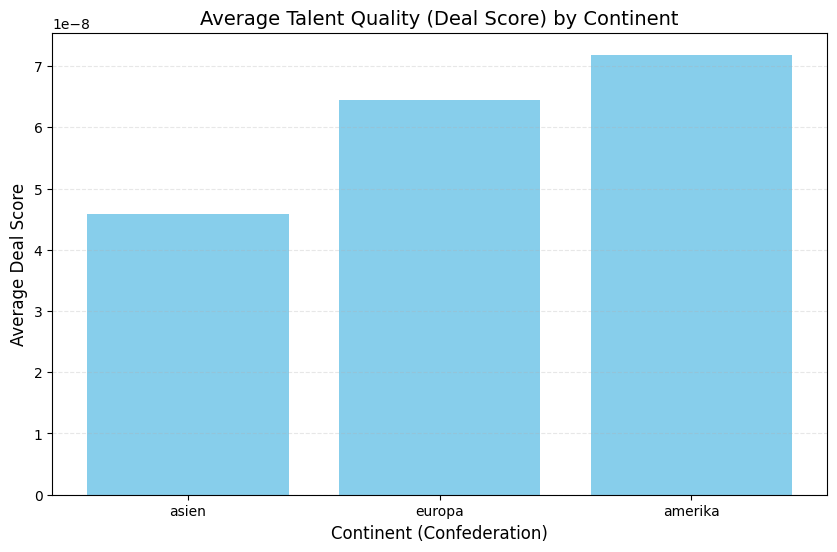

In [56]:
df_scout['market_value_in_eur'] = pd.to_numeric(df_scout['market_value_in_eur'], errors='coerce')
df_scout['age'] = pd.to_numeric(df_scout['age'], errors='coerce').fillna(25)
df_scout['total_appearances'] = pd.to_numeric(df_scout['total_appearances'], errors='coerce').fillna(0)
df_scout['general_rating'] = df_scout['total_appearances'] / df_scout['age']
df_scout['deal_score'] = df_scout['general_rating'] / (df_scout['market_value_in_eur'] * df_scout['age'])
continent_avg = df_scout.groupby('confederation')['deal_score'].mean().sort_values()
plt.figure(figsize=(10, 6))
plt.bar(continent_avg.index, continent_avg.values, color='skyblue')
plt.title('Average Talent Quality (Deal Score) by Continent', fontsize=14)
plt.xlabel('Continent (Confederation)', fontsize=12)
plt.ylabel('Average Deal Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

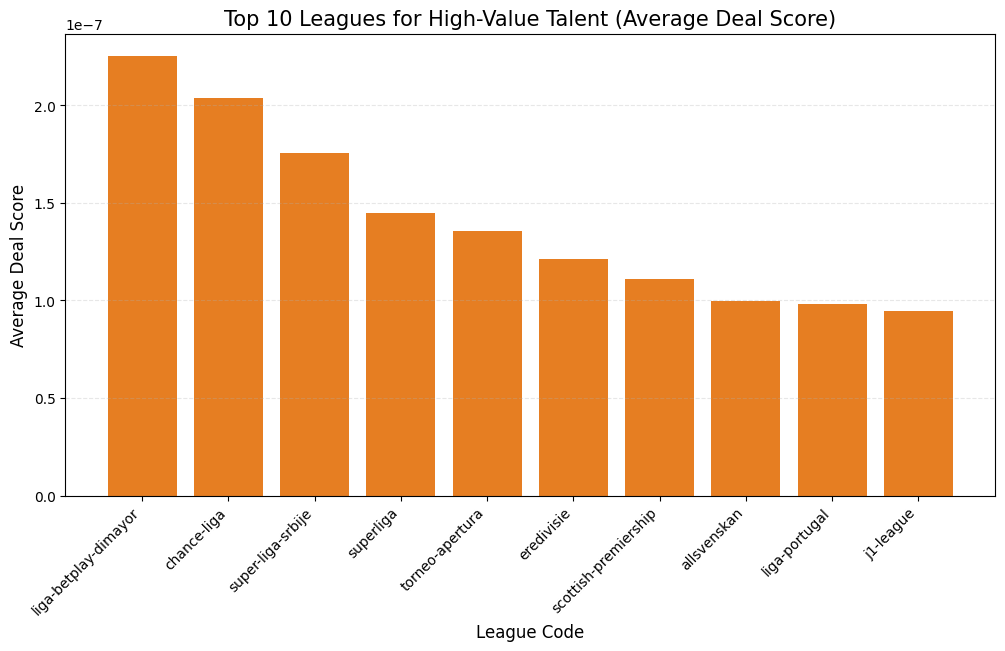

In [57]:
league_avg = df_scout.groupby('competition_code')['deal_score'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.bar(league_avg.index, league_avg.values, color='#e67e22')
plt.title('Top 10 Leagues for High-Value Talent (Average Deal Score)', fontsize=15)
plt.xlabel('League Code', fontsize=12)
plt.ylabel('Average Deal Score', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.show()

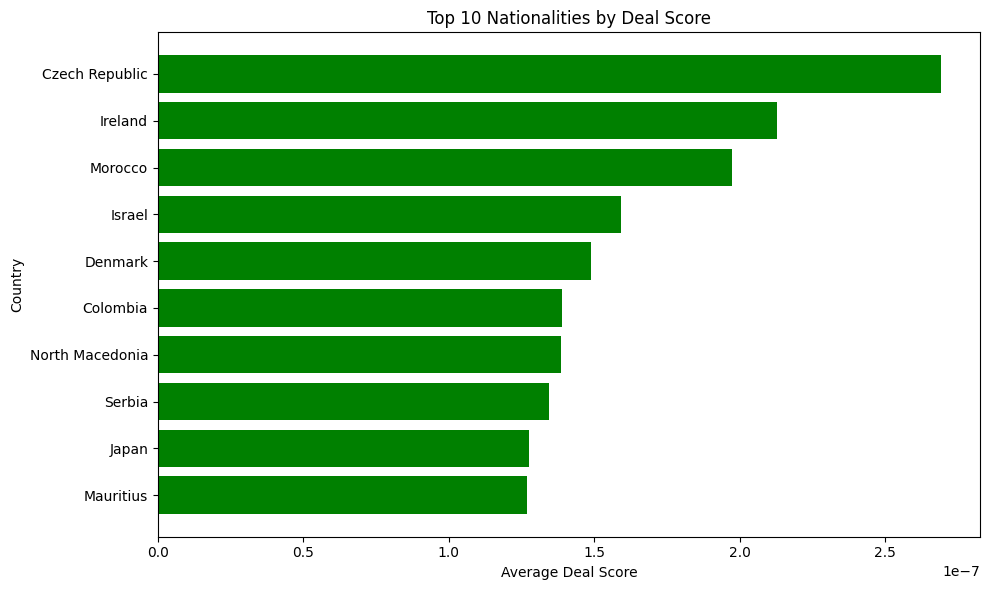

In [58]:
top10_nations = df_scout.groupby('country_of_citizenship')['deal_score'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10_nations.index, top10_nations.values, color='green')
plt.gca().invert_yaxis()
plt.title('Top 10 Nationalities by Deal Score')
plt.xlabel('Average Deal Score')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [59]:
top10_LM.to_csv('top10_LM.csv', index=False)
top10_RM.to_csv('top10_RM.csv', index=False)
top10_AM.to_csv('top10_AM.csv', index=False)
top10_DM.to_csv('top10_DM.csv', index=False)
top10_CM.to_csv('top10_CM.csv', index=False)
top10_GK.to_csv('top10_GK.csv', index=False)
top10_LB.to_csv('top10_LB.csv', index=False)
top10_RB.to_csv('top10_RB.csv', index=False)
top10_CB.to_csv('top10_CB.csv', index=False)
top10_LW.to_csv('top10_LW.csv', index=False)
top10_RW.to_csv('top10_RW.csv', index=False)
top10_SS.to_csv('top10_SS.csv', index=False)
top10_CF.to_csv('top10_CF.csv', index=False)
df_scout.to_csv('df_scout.csv', index=False)

In [60]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.sidebar.title("Navigation")
page = st.sidebar.radio("Aller vers :", [
    "1. Introduction",
    "2. Méthodologie & Scoring",
    "3. Exploration des Données",
    "4. Top 10 par Position",
    "5. Analyses Graphiques"
])


if page == "1. Introduction":
    st.title("⚽ SCOUT INTELLIGENCE")
    st.header("Système d'Aide à la Décision pour le Recrutement")
    st.subheader("Présentation du Projet")
    st.markdown("""
    Ce projet de vise à transformer le recrutement de football.
    En analysant des millions de données, nous calculons un **Deal Score** pour identifier les joueurs qui apportent une performance maximale pour un coût minimal.
    """)
    st.subheader("La Problématique")
    st.error("**Manchester United & Antony :** 95M€ investis sur la réputation. Échec statistique.")
    st.error("**Juventus & Paul Pogba :** Risque financier lié à la fiabilité physique.")
    st.success("**Notre Solution :** Le modèle 'Deal Stars' identifie les talents à fort ROI.")


elif page == "2. Méthodologie & Scoring":
    st.title("🧠 Méthodologie de Scoring")
    st.subheader("1. La Formule du Deal Score")
    st.latex(r'''
    Deal Score = \frac{Rating \times \text{Minutes Jouées}}{\text{Valeur de Marché} \times \text{Âge}}
    ''')
    st.info("""
    **Explication des paramètres :**
    - **Rating :** Performance technique spécifique au poste.
    - **Minutes :** Disponibilité et fiabilité physique.
    - **Valeur :** Coût d'acquisition sur le marché.
    - **Âge :** Facteur de risque et potentiel de revente.
    """)


elif page == "3. Exploration des Données":
    st.title("🔍 Exploration")
    df_scout = pd.read_csv('df_scout.csv')
    st.dataframe(df_scout)


elif page == "4. Top 10 par Position":
    st.title("🏆 Top 10 Prospects")
    sub_pos = st.selectbox("Choisir une sous-position :", [
        "Gardien (GK)", "Défenseur Central (CB)", "Latéral Gauche (LB)", "Latéral Droit (RB)",
        "Milieu Défensif (DM)", "Milieu Central (CM)", "Milieu Offensif (AM)",
        "Milieu Gauche (LM)", "Milieu Droit (RM)",
        "Ailier Gauche (LW)", "Ailier Droit (RW)", "Second Attaquant (SS)", "Buteur (CF)"
    ])
mapping = {
        "Gardien (GK)": "top10_GK.csv", "Défenseur Central (CB)": "top10_CB.csv",
        "Latéral Gauche (LB)": "top10_LB.csv", "Latéral Droit (RB)": "top10_RB.csv",
        "Milieu Défensif (DM)": "top10_DM.csv", "Milieu Central (CM)": "top10_CM.csv",
        "Milieu Offensif (AM)": "top10_AM.csv", "Milieu Gauche (LM)": "top10_LM.csv",
        "Milieu Droit (RM)": "top10_RM.csv", "Ailier Gauche (LW)": "top10_LW.csv",
        "Ailier Droit (RW)": "top10_RW.csv", "Second Attaquant (SS)": "top10_SS.csv",
        "Buteur (CF)": "top10_CF.csv"
    }
    df_display = pd.read_csv(mapping[sub_pos])
    st.table(df_display[['player_code', 'current_club_name', 'age', 'deal_score']])


elif page == "5. Analyses Graphiques":
    st.title("📈 Représentation Graphique")
    df_scout = pd.read_csv('df_scout.csv')


    st.subheader("Qualité Moyenne des Talents par Continent")
    continent_avg = df_scout.groupby('confederation')['deal_score'].mean().sort_values()
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    ax1.bar(continent_avg.index, continent_avg.values, color='skyblue')
    ax1.set_ylabel('Average Deal Score')
    st.pyplot(fig1)


    st.subheader("Top 10 Ligues (High-Value Talent)")
    league_avg = df_scout.groupby('competition_code')['deal_score'].mean().sort_values(ascending=False).head(10)
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    ax2.bar(league_avg.index, league_avg.values, color='#e67e22')
    plt.xticks(rotation=45)
    st.pyplot(fig2)


    st.subheader("Top 10 Nationalités par Deal Score")
    top10_nations = df_scout.groupby('country_of_citizenship')['deal_score'].mean().sort_values(ascending=False).head(10)
    fig3, ax3 = plt.subplots(figsize=(10, 6))
    ax3.barh(top10_nations.index, top10_nations.values, color='green')
    ax3.invert_yaxis()
    st.pyplot(fig3)


Overwriting app.py


In [61]:
!curl ipv4.icanhazip.com

34.16.166.144


In [ ]:
!pip install streamlit -q
!streamlit run app.py & npx localtunnel --port 8501

⠙

⠹⠸⠼⠴⠦⠧Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-05-08 20:52:01.849 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.166.144:8501

